# House Price Prediction Using Machine Learning

This project develops and evaluates multiple machine learning regression models to predict house prices using a real estate dataset from India.

The workflow includes exploratory data analysis (EDA), data preprocessing, feature scaling, model training, hyperparameter tuning, performance evaluation, and model comparison.

# Import Libraries

Import the required libraries for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [53]:
import numpy as np
import pandas as pd
import joblib


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

# Load Dataset

Load the house price dataset and inspect the first few records.

In [54]:
df = pd.read_csv("House Price India.csv")

df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


# Exploratory Data Analysis (EDA)

Explore the dataset by examining its structure, summary statistics, missing values, and feature distributions.

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

In [56]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,...,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04
mean,6.762821e+09,42604.546412,3.379233,2.129557,2098.156851,1.509369e+04,1.502326,0.007661,0.232848,3.430399,...,1970.929817,90.930228,122033.064300,52.792843,-114.403996,1996.641836,12754.003078,2.012244,64.951433,5.388063e+05
std,6.237162e+03,67.343747,0.938655,0.769955,928.218740,3.792089e+04,0.540241,0.087196,0.765651,0.664047,...,29.491743,416.230218,19.081451,0.137525,0.141325,691.078387,26059.234785,0.817312,8.936129,3.672294e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010500e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.500000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [57]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values[missing_values["Missing Values"] > 0]

,Missing Values,Percentage


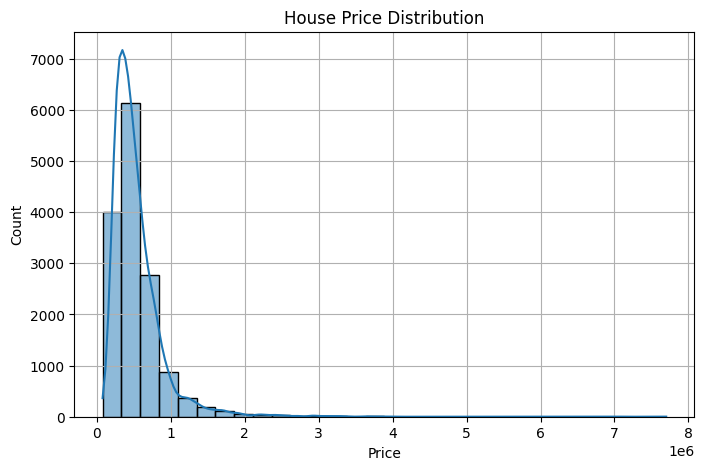

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Price"],
    bins=30,
    kde=True
)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.grid(True)

plt.show()

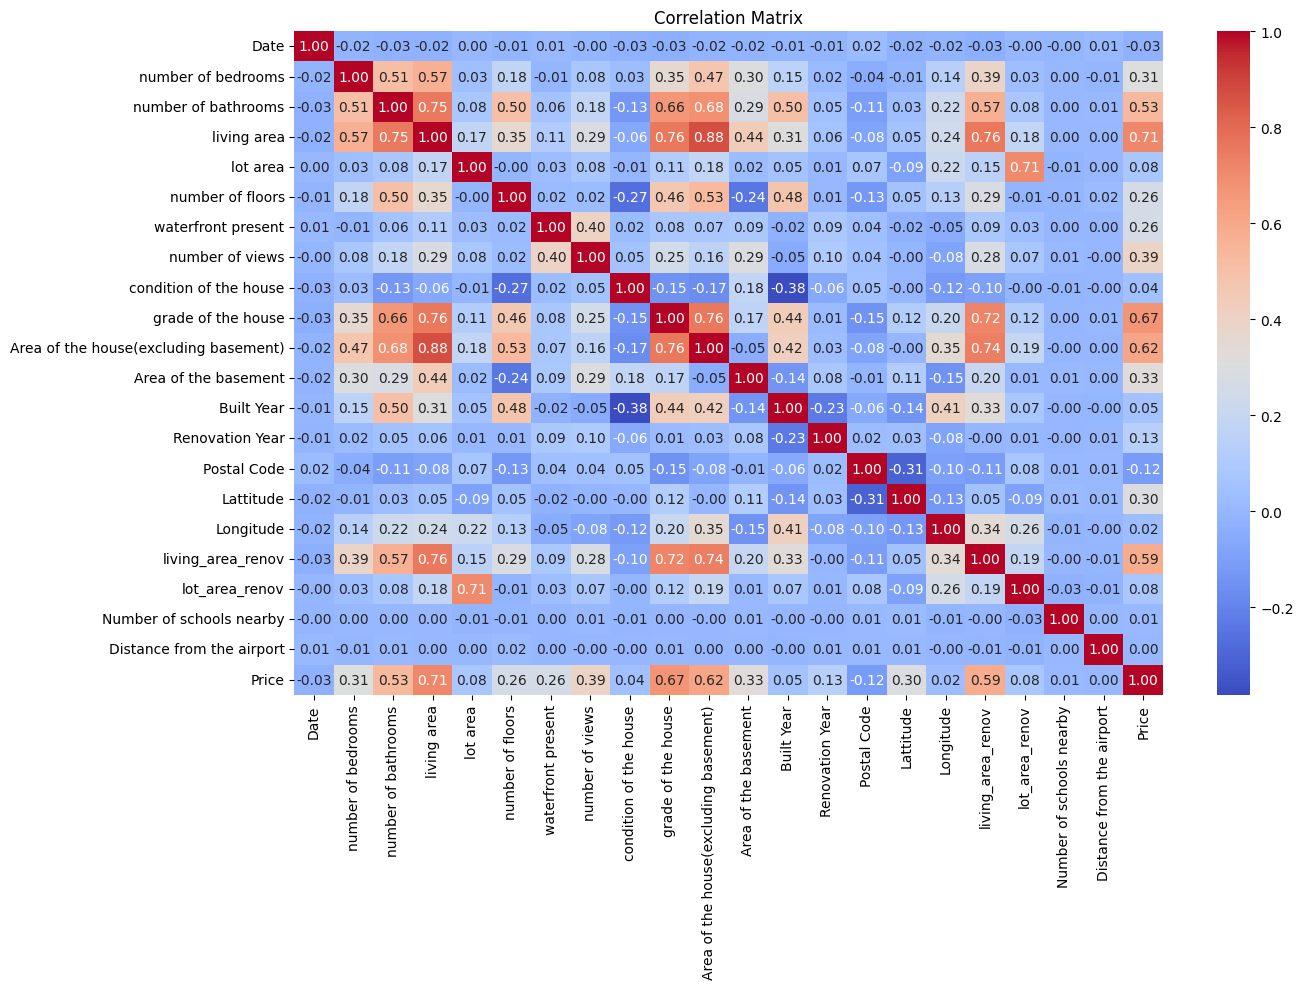

In [59]:
plt.figure(figsize=(14,10))

correlation_matrix = (
    df
    .drop(columns=["id"])
    .corr(numeric_only=True)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [60]:
correlation = (
    df
    .drop(columns=["id"])
    .corr(numeric_only=True)["Price"]
    .sort_values(ascending=False)
)

correlation_df = correlation.to_frame(name="Correlation with Price")

display(correlation_df)

most_correlated_feature = correlation.index[1]

print(f"\nMost correlated feature: {most_correlated_feature}")

,Correlation with Price
Price,1.000000
living area,0.712276
grade of the house,0.671805
Area of the house(excluding basement),0.615179
living_area_renov,0.585021
number of bathrooms,0.532031
number of views,0.394954
Area of the basement,0.330499
number of bedrooms,0.308165
Lattitude,0.297570



Most correlated feature: living area


# Data Preprocessing

Prepare the dataset by removing unnecessary features, selecting the target variable, and separating the input features from the target.

In [61]:
df = df.drop(columns=["id"])
df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_")
)

# Features and target
X = df.drop(columns=["Price"])
y = df["Price"]

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (14619, 21)
Target Shape : (14619,)


# Train and Test Split

Split the dataset into training and testing sets.

- Training Set (80%)
- Testing Set (20%)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (11695, 21)
Testing Set  : (2924, 21)


# Model Evaluation Function

Create a reusable function to evaluate regression models using common performance metrics.

In [63]:
results = []

def evaluate_model(name, model, X_test, y_test):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    })

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE      : {mae:.2f}")
    print(f"MSE      : {mse:.2f}")
    print(f"RMSE     : {rmse:.2f}")
    print(f"R² Score : {r2:.4f}")

# Simple Linear Regression

Train a Simple Linear Regression model using the feature with the strongest correlation to house prices.

This model serves as a baseline by evaluating how well a single predictor can estimate the target variable before introducing more complex regression models.

In [64]:
simple_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

X_train_single = X_train[["living_area"]]
X_test_single = X_test[["living_area"]]

simple_lr.fit(X_train_single, y_train)

y_pred_simple = simple_lr.predict(X_test_single)

print("Simple Linear Regression Performance")
print("-" * 40)
print(f"MAE      : {mean_absolute_error(y_test, y_pred_simple):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_simple)):.2f}")
print(f"R² Score : {r2_score(y_test, y_pred_simple):.4f}")

Simple Linear Regression Performance
----------------------------------------
MAE      : 169625.25
RMSE     : 263098.62
R² Score : 0.5323


## Regression Line

Visualize the relationship between the most influential feature and the target variable.

The fitted regression line illustrates how the predicted house prices change with the selected feature.

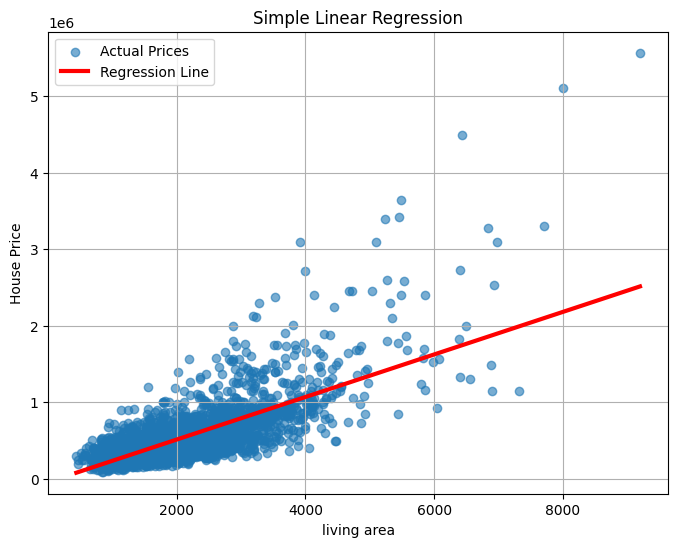

In [65]:
sorted_idx = np.argsort(X_test_single["living_area"].values)

plt.figure(figsize=(8,6))

plt.scatter(
    X_test_single["living_area"],
    y_test,
    alpha=0.6,
    label="Actual Prices"
)

plt.plot(
    X_test_single["living_area"].values[sorted_idx],
    y_pred_simple[sorted_idx],
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.title("Simple Linear Regression")
plt.xlabel(most_correlated_feature)
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

plt.show()

# Multiple Linear Regression

Train a Multiple Linear Regression model using all available features as a baseline for multivariable regression.

In [66]:
multiple_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

multiple_lr.fit(X_train, y_train)

evaluate_model(
    "Multiple Linear Regression",
    multiple_lr,
    X_test,
    y_test
)


Multiple Linear Regression
----------------------------------------
MAE      : 125366.18
MSE      : 44107941320.96
RMSE     : 210018.91
R² Score : 0.7020


## Actual vs Predicted Prices

Compare the predicted house prices with the actual values. A well-performing model should produce predictions close to the diagonal reference line.

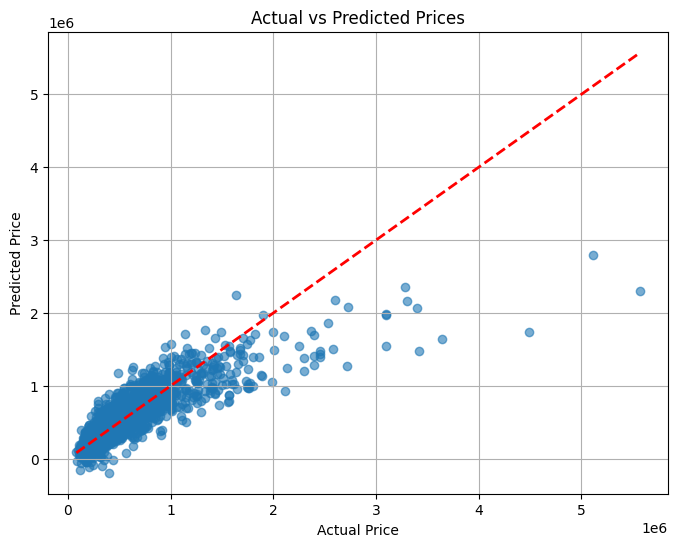

In [67]:
y_pred_lr = multiple_lr.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()

## Residual Plot

Visualize the prediction errors of the Multiple Linear Regression model.
A good model should produce residuals that are randomly distributed around zero.

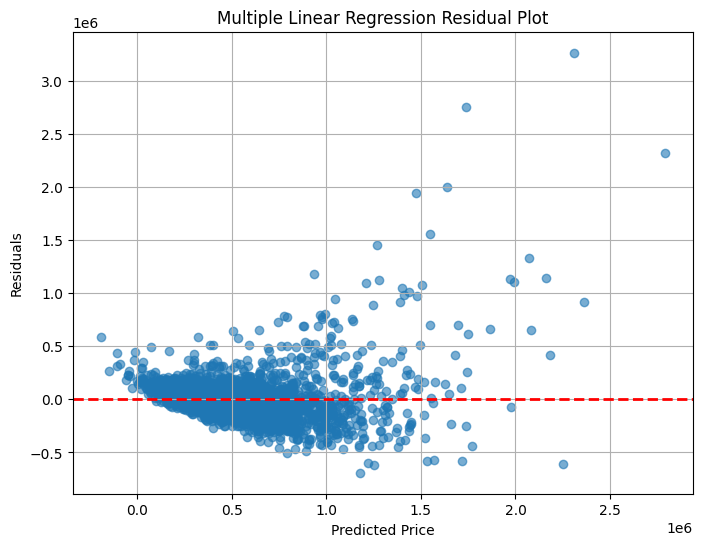

In [68]:
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_lr,
    residuals_lr,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Multiple Linear Regression Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.grid(True)

plt.show()

# Polynomial Regression

Polynomial Regression extends Linear Regression by creating polynomial combinations of the input features. This allows the model to capture nonlinear relationships while still using a linear regression algorithm.

To identify the most suitable model complexity, the polynomial degree is optimized using GridSearchCV.

In [69]:
poly_pipe = Pipeline([
    ("poly", PolynomialFeatures()),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

poly_grid = {
    "poly__degree": [2, 3]
}

poly_search = GridSearchCV(
    poly_pipe,
    poly_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

poly_search.fit(X_train, y_train)

best_poly = poly_search.best_estimator_

print("Best Parameters:", poly_search.best_params_)
print("Best Cross-Validation R²:", poly_search.best_score_)

evaluate_model(
    "Polynomial Regression",
    best_poly,
    X_test,
    y_test
)

Best Parameters: {'poly__degree': 2}
Best Cross-Validation R²: 0.8092161165703964

Polynomial Regression
----------------------------------------
MAE      : 101360.98
MSE      : 26885557548.24
RMSE     : 163968.16
R² Score : 0.8183


## Actual vs Predicted Prices

Compare the predicted house prices generated by the optimized Polynomial Regression model with the actual house prices. Predictions closer to the diagonal reference line indicate better model performance.

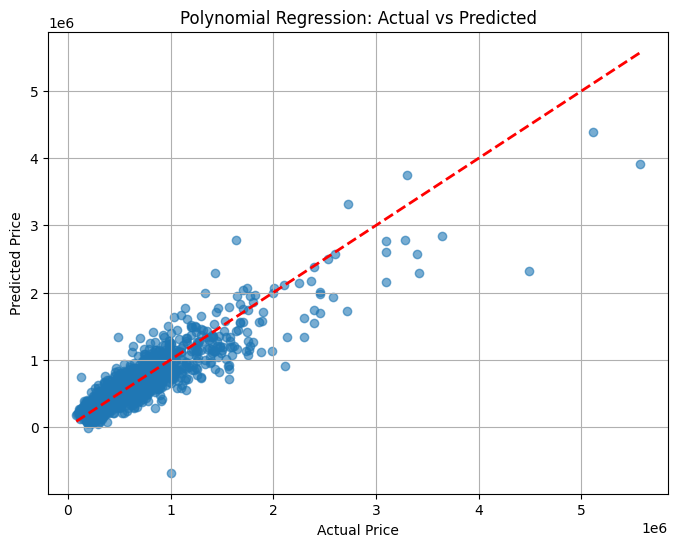

In [70]:
y_pred_poly = best_poly.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_poly,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Polynomial Regression: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()

## Residual Plot

Residuals represent the difference between the actual and predicted house prices. An effective regression model should produce residuals that are randomly distributed around zero without clear patterns.

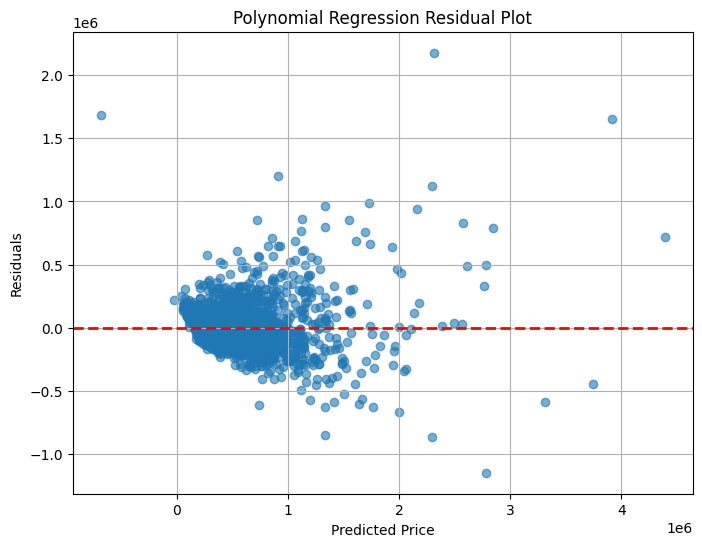

In [71]:
residuals_poly = y_test - y_pred_poly

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_poly,
    residuals_poly,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Polynomial Regression Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.grid(True)

plt.show()

# Decision Tree Regressor

Optimize a Decision Tree Regressor using GridSearchCV to identify the best hyperparameters.

In [72]:
dt_pipe = Pipeline([
    ("regressor", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

dt_grid = {
    "regressor__max_depth": [5, 10, 15, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4]
}

dt_search = GridSearchCV(
    dt_pipe,
    dt_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


dt_search.fit(X_train, y_train)

print("Best Parameters:")
print(dt_search.best_params_)

best_dt = dt_search.best_estimator_

evaluate_model(
    "Decision Tree",
    best_dt,
    X_test,
    y_test
)


Best Parameters:
{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10}

Decision Tree
----------------------------------------
MAE      : 89297.02
MSE      : 26670859223.99
RMSE     : 163312.15
R² Score : 0.8198


## Actual vs Predicted Prices

Compare the predicted prices generated by the Decision Tree model with the actual house prices.

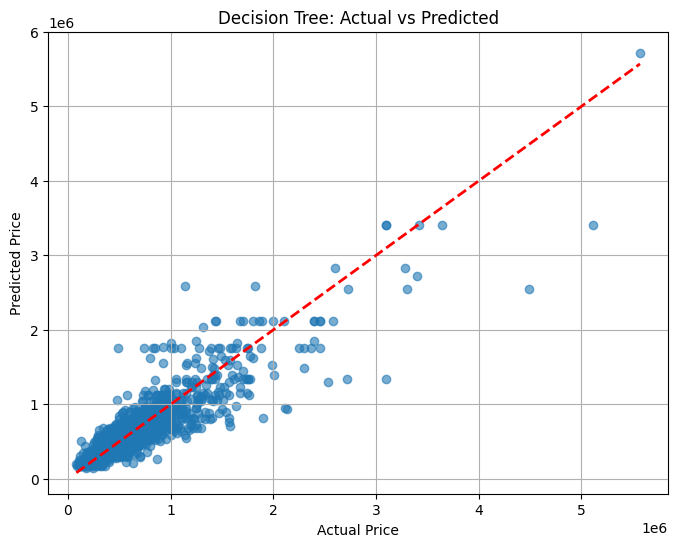

In [73]:
y_pred_dt = best_dt.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_dt,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()

## Residual Plot

Display the residual errors of the Decision Tree model.

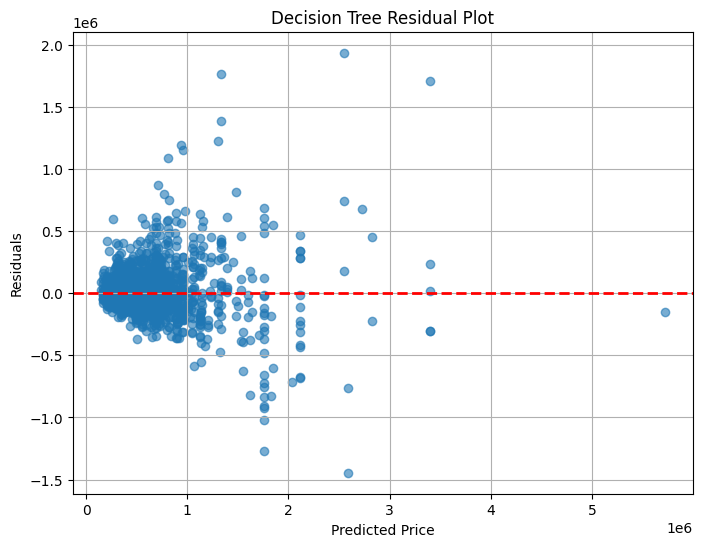

In [74]:
residuals_dt = y_test - y_pred_dt

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_dt,
    residuals_dt,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Decision Tree Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.grid(True)

plt.show()

# Random Forest Regressor

Train and optimize a Random Forest Regressor using GridSearchCV.

In [75]:
rf_pipe = Pipeline([
    ("regressor", RandomForestRegressor(random_state=RANDOM_STATE))
])

rf_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}

rf_search = GridSearchCV(
    rf_pipe,
    rf_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_search.best_params_)

best_rf = rf_search.best_estimator_

evaluate_model(
    "Random Forest",
    best_rf,
    X_test,
    y_test
)

Best Parameters:
{'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}

Random Forest
----------------------------------------
MAE      : 69636.33
MSE      : 17375926579.92
RMSE     : 131817.78
R² Score : 0.8826


## Actual vs Predicted Prices

Evaluate the Random Forest model by comparing predicted and actual house prices.

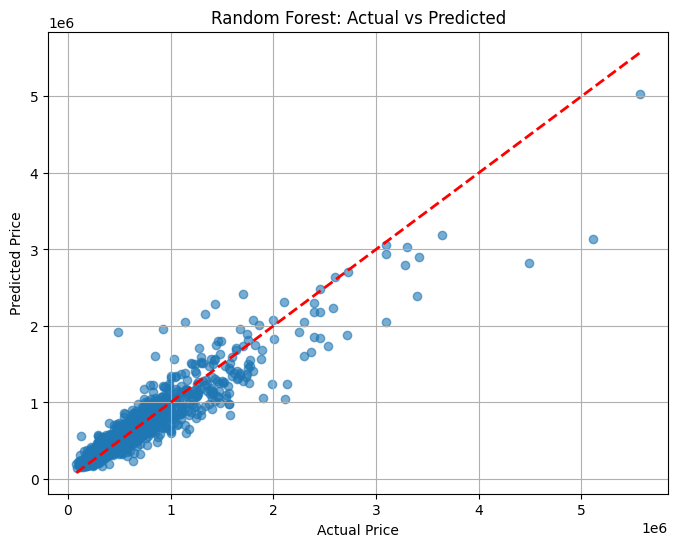

In [76]:
y_pred_rf = best_rf.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()

## Residual Plot

Visualize the residual errors of the Random Forest model.

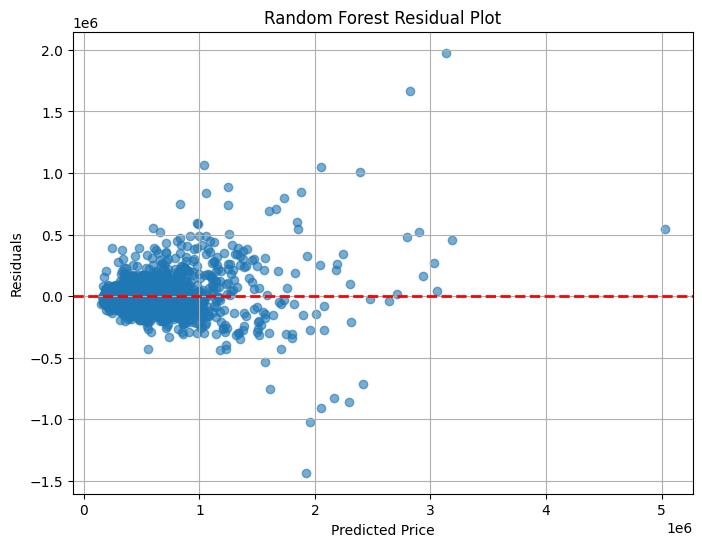

In [77]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_rf,
    residuals_rf,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Random Forest Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.grid(True)

plt.show()

## Feature Importance

Display the most influential features used by the Random Forest model for predicting house prices.

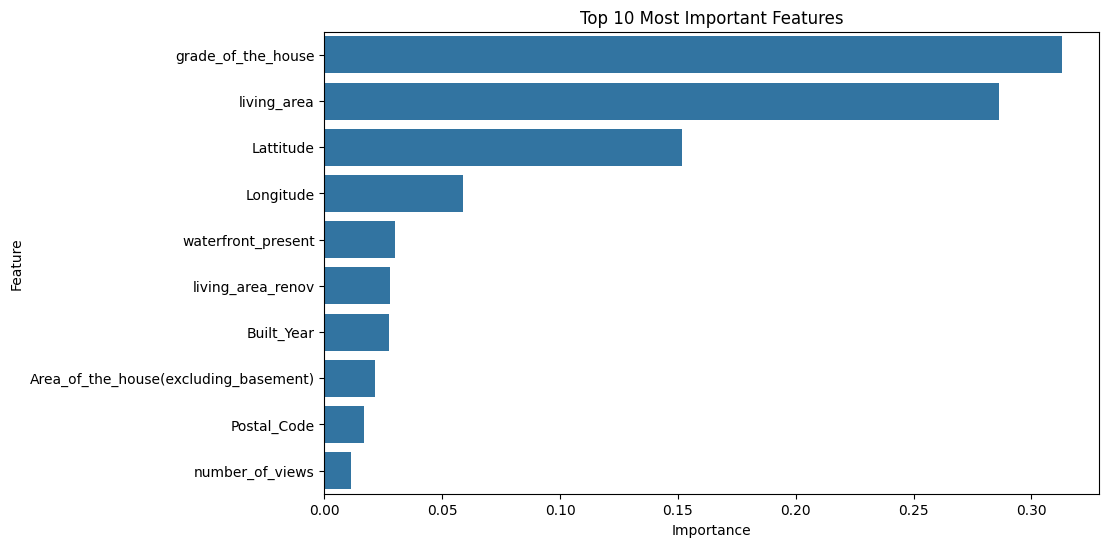

In [78]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.named_steps["regressor"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

top_features = feature_importance.head(10)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()

# Model Comparison

Compare the performance of all regression models using the evaluation metrics.

In [79]:
results = pd.DataFrame(results)

results = results.round(4)

results.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R² Score
3,Random Forest,69636.3277,1.737593e+10,131817.7779,0.8826
2,Decision Tree,89297.0223,2.667086e+10,163312.1527,0.8198
1,Polynomial Regression,101360.9828,2.688556e+10,163968.1602,0.8183
0,Multiple Linear Regression,125366.1794,4.410794e+10,210018.9071,0.7020


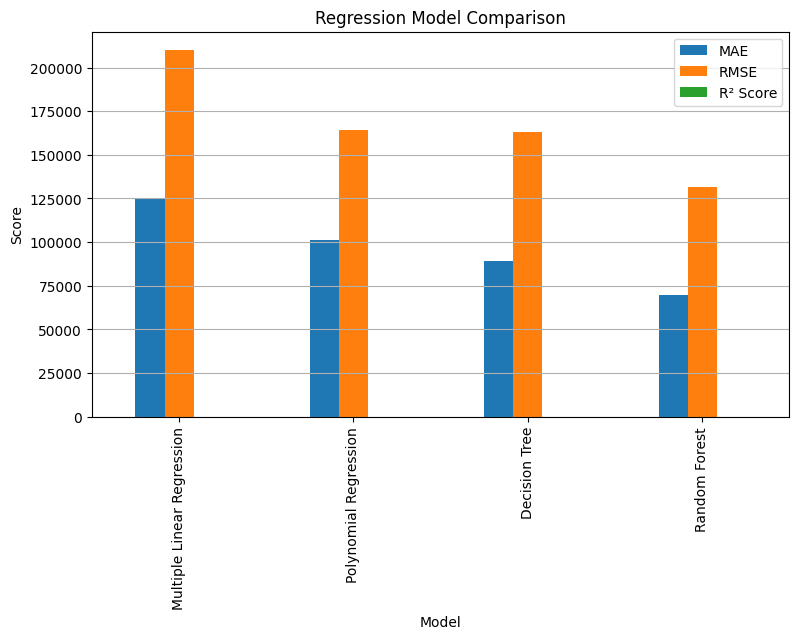

In [80]:
results.set_index("Model")[["MAE", "RMSE", "R² Score"]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Regression Model Comparison")

plt.ylabel("Score")

plt.grid(axis="y")

plt.show()

# Save the Best Model

Save the best-performing regression model for future predictions.

In [81]:
joblib.dump(best_rf, "house_price_model.pkl")

print(type(best_rf))

print("Model saved successfully.")

<class 'sklearn.pipeline.Pipeline'>
Model saved successfully.


# Conclusion

Three regression models were developed and evaluated for predicting house prices.

- Multiple Linear Regression provided a strong baseline.
- Decision Tree Regression captured nonlinear relationships within the dataset.
- Random Forest achieved the best overall performance by combining multiple decision trees into an ensemble model.

The project demonstrated a complete machine learning workflow, including data preprocessing, model training, hyperparameter tuning, evaluation, visualization, feature importance analysis, and model persistence.